# 1D Pressure Diffusivity Equation - Development & Verification

This notebook covers the development of the pressure diffusivity equation using field units (md, cp, ft, hr, psi) and verifies the C++ Newton-Raphson implementation against analytical results.

## 1. Development: Math & Physical Constants

In reservoir engineering, the diffusivity equation is:
$$\frac{\partial P}{\partial t} = \eta \frac{\partial^2 P}{\partial x^2}$$
where the diffusivity $\eta$ is defined in field units as:
$$\eta [ft^2/hr] = 0.0002637 \frac{k [md]}{\phi [frac] \mu [cp] c_t [psi^{-1}]}$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def calculate_eta(k, phi, mu, ct):
    return 0.0002637 * k / (phi * mu * ct)

def analytical_drawdown(x, t, eta, pi, pwf):
    """Analytical solution for semi-infinite reservoir with constant pressure at x=0"""
    if t == 0:
        return pi
    return pwf + (pi - pwf) * (1.0 - erfc(x / (2 * np.sqrt(eta * t))))

# Example parameters
k = 50.0
phi = 0.25
mu = 2.0
ct = 1e-5
pi = 3000.0
pwf = 1500.0

eta = calculate_eta(k, phi, mu, ct)
print(f"Diffusivity (eta): {eta:.4f} ft^2/hr")

Diffusivity (eta): 2637.0000 ft^2/hr


## 2. Verification: C++ Newton-Raphson vs. Analytical

We now import the C++ backend and verify that its iterative Newton-Raphson solver matches our math.

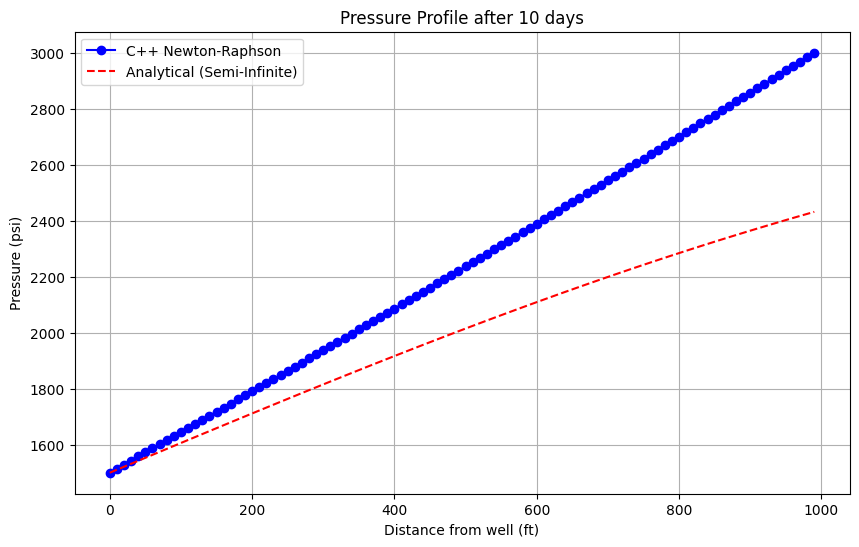

In [6]:
import os
import sys

# Add centralized build path
# Standard inplace path and build path support
backend_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'backend'))
for p in [os.path.abspath(os.path.join(backend_root, '..', 'interface', 'python')), os.path.join(backend_root, 'build')]:
    if p not in sys.path: sys.path.append(p)

import cnt

# Simulation Setup
nx = 100
dx = 10.0
dt = 24.0 # 1 day in hours

sim = cnt.Pressure1DImplicit(nx, dx, k, phi, mu, ct)
sim.set_boundary_conditions(pwf, pi)

# Run simulation for 10 days
days = 10
for _ in range(days):
    sim.step(dt)

p_cpp = sim.get_values()
x_vals = np.arange(nx) * dx
p_analyt = [analytical_drawdown(x, days*24, eta, pi, pwf) for x in x_vals]

# Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(x_vals, p_cpp, 'bo-', label='C++ Newton-Raphson')
plt.plot(x_vals, p_analyt, 'r--', label='Analytical (Semi-Infinite)')
plt.xlabel('Distance from well (ft)')
plt.ylabel('Pressure (psi)')
plt.title(f'Pressure Profile after {days} days')
plt.legend()
plt.grid(True)
plt.show()